<a href="https://colab.research.google.com/github/silvatria/PCVK_Ganjil_2026/blob/main/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
#===== SEL IDENTITAS JANGAN DIHAPUS, HARUS SEL PERTAMA =====
import sys, platform, hashlib, datetime, zoneinfo

NAMA = 'Silva Tria Alfares'
NIM = '254107023001'  # ganti dengan NIM Anda
N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1)
}

waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))
print('NAMA  :', NAMA)
print('NIM   :', NIM, 'N =', N)
for k, v in PARAM.items():
    print('%-6s: %s' % (k, v))
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
kunci = NIM + ' ' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])
print('SISTEM:', sys.version.split()[0], platform.platform())

NAMA  : Silva Tria Alfares
NIM   : 254107023001 N = 1
bins  : 16
clip  : 1.5
tile  : 3
L     : 4
WAKTU : 2026-10-03 18:27:25 WIB
TOKEN : e320dc538680c0c2
SISTEM: 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39


In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


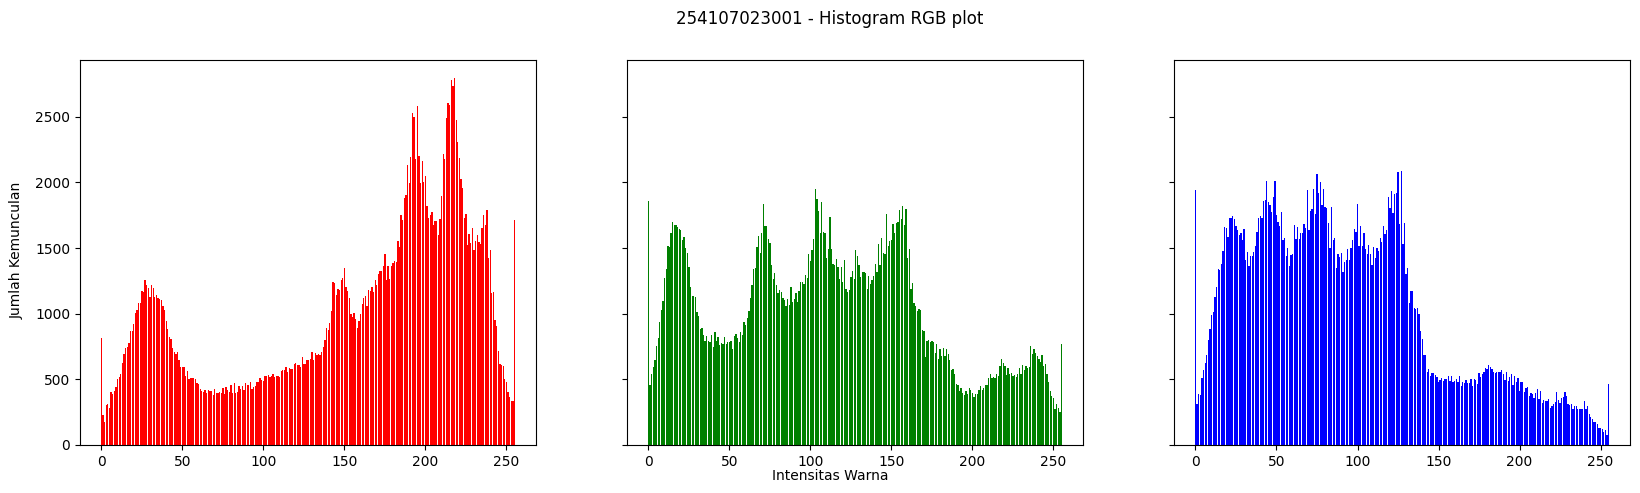

In [11]:
# PRAKTIKUM E1

# Import library dasar
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math, os, glob

# Definisikan direktori
CONTOH = '/content/drive/MyDrive/2C/PCVK/Images'
BASE = '/content/drive/MyDrive/2C/PCVK/Images/' + NIM

# Kode Membuat Histogram RGB Manual
img = cv.imread(CONTOH + '/lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle(NIM + ' - Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')
plt.show()

In [25]:
# PERTANYAAN PRAKTIKUM E1
# Sel 1: Pertanyaan 1 (Perbandingan Histogram Manual, NumPy, & cv.calcHist)

import os
import cv2 as cv
import numpy as np

def test_histogram_methods(image_path):
    if not os.path.exists(image_path):
        print(f"ERROR: File tidak ditemukan di: {image_path}")
        return

    img_bgr = cv.imread(image_path)
    img_rgb = cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB)

    # Ambil kanal Merah (Red / index 0) sebagai sampel
    channel_data = img_rgb[:, :, 0]

    # A. Manual
    hist_manual = [0] * 256
    for y in range(channel_data.shape[0]):
        for x in range(channel_data.shape[1]):
            hist_manual[channel_data[y, x]] += 1
    hist_manual = np.array(hist_manual)

    # B. NumPy histogram
    hist_np, _ = np.histogram(channel_data, bins=256, range=(0, 256))

    # C. OpenCV calcHist
    hist_cv = cv.calcHist([img_rgb], [0], None, [256], [0, 256]).flatten().astype(int)

    # Hitung selisih maksimum
    diff_np = np.max(np.abs(hist_manual - hist_np))
    diff_cv = np.max(np.abs(hist_manual - hist_cv))

    print(f"File: {image_path}")
    print(f"Selisih Max (Manual vs NumPy)      : {diff_np}")
    print(f"Selisih Max (Manual vs cv.calcHist): {diff_cv}\n")

print("--- Menjalankan Pertanyaan 1 ---")
test_histogram_methods(CONTOH + '/lena.jpg')
test_histogram_methods(BASE + '/KTM1b.jpg')

--- Menjalankan Pertanyaan 1 ---
File: /content/drive/MyDrive/2C/PCVK/Images/lena.jpg
Selisih Max (Manual vs NumPy)      : 0
Selisih Max (Manual vs cv.calcHist): 0

File: /content/drive/MyDrive/2C/PCVK/Images/254107023001/KTM1b.jpg
Selisih Max (Manual vs NumPy)      : 0
Selisih Max (Manual vs cv.calcHist): 0



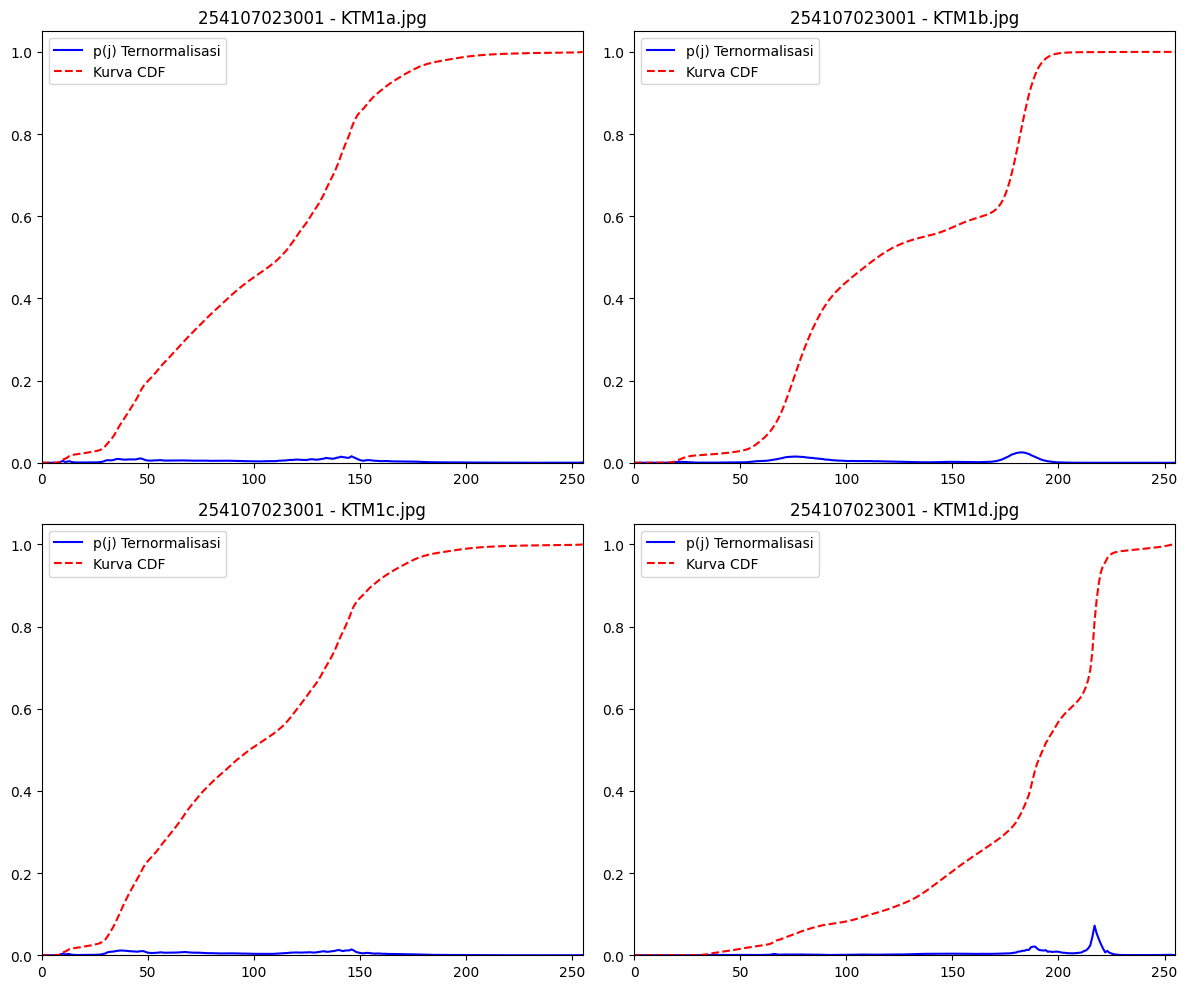

In [26]:
# PERTANYAAN PRAKTIKUM E1
# Pertanyaan 2 (Plot Histogram Ternormalisasi)

import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.flatten()

for i, filename in enumerate(ktm_files):
    img_path = os.path.join(BASE, filename)
    if not os.path.exists(img_path):
        print(f"Peringatan: {filename} tidak ditemukan di {BASE}")
        continue

    gray = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    hist, _ = np.histogram(gray, bins=256, range=(0, 256))
    p_j = hist / gray.size
    cdf = np.cumsum(p_j)

    axs[i].plot(p_j, label='p(j) Ternormalisasi', color='blue')
    axs[i].plot(cdf, label='Kurva CDF', color='red', linestyle='--')
    axs[i].set_title(f"{NIM} - {filename}")
    axs[i].set_xlim([0, 255])
    axs[i].set_ylim([0, 1.05])
    axs[i].legend()

plt.tight_layout()
plt.show()

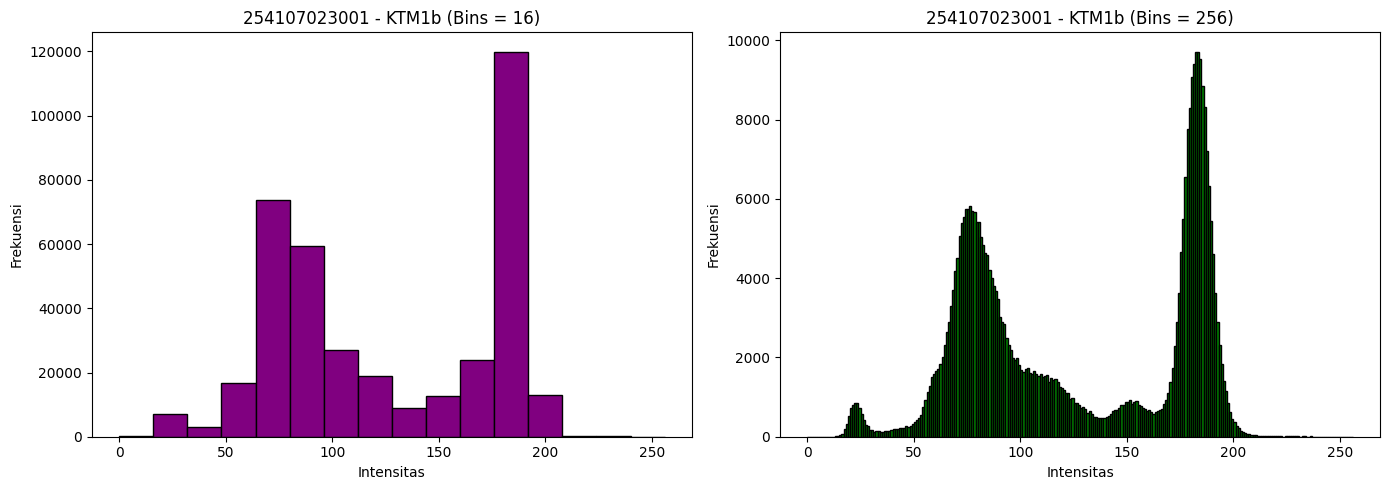

In [20]:
# PERTANYAAN PRAKTIKUM E1
# Pertanyaan 3 (Perbandingan Custom Bins vs 256 Bins)

import os
import cv2 as cv
import matplotlib.pyplot as plt

path_ktm1b = BASE + '/KTM1b.jpg'
if os.path.exists(path_ktm1b):
    gray_ktm1b = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)
    custom_bins = PARAM['bins']

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    axs[0].hist(gray_ktm1b.ravel(), bins=custom_bins, range=(0, 256), color='purple', edgecolor='black')
    axs[0].set_title(f"{NIM} - KTM1b (Bins = {custom_bins})")
    axs[0].set_xlabel("Intensitas")
    axs[0].set_ylabel("Frekuensi")

    axs[1].hist(gray_ktm1b.ravel(), bins=256, range=(0, 256), color='green', edgecolor='black')
    axs[1].set_title(f"{NIM} - KTM1b (Bins = 256)")
    axs[1].set_xlabel("Intensitas")
    axs[1].set_ylabel("Frekuensi")

    plt.tight_layout()
    plt.show()
else:
    print(f"File KTM1b.jpg tidak ditemukan di {path_ktm1b}")

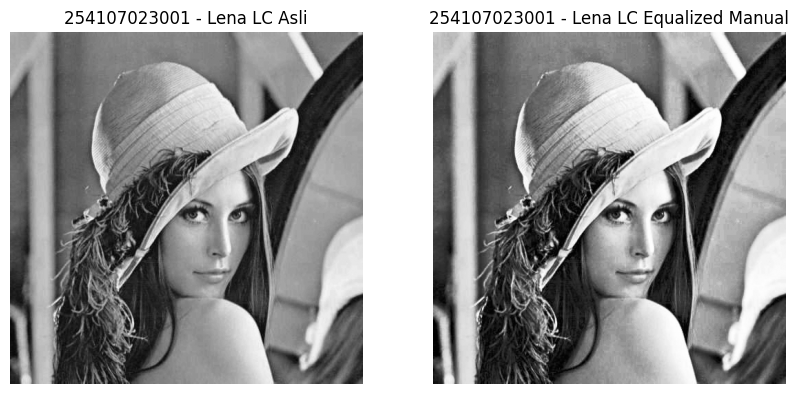

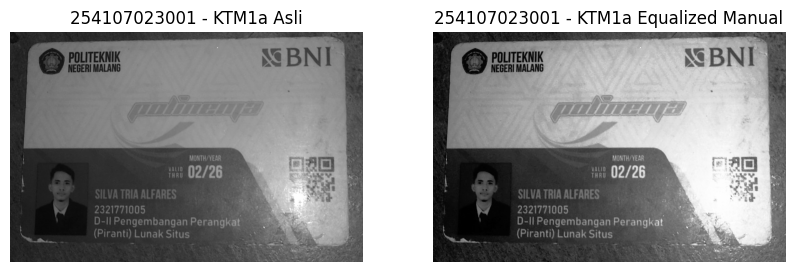

In [22]:
# E-2 PERCOBAAN HISTOGRAM EQUALIZATION
# 1. Implementasi Manual Histogram Equalization
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def manual_histogram_equalization(gray_img):
    # 1. Hitung frekuensi kemunculan piksel (Histogram)
    hist, _ = np.histogram(gray_img.flatten(), 256, [0, 256])

    # 2. Jumlah kumulatif frekuensi (CDF)
    cdf = hist.cumsum()

    # 3. Normalisasi CDF ke rentang 0-255
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    cdf = np.ma.filled(cdf_m, 0).astype('uint8')

    # 4. Transformasi piksel citra berdasarkan nilai CDF
    img_equalized = cdf[gray_img]
    return img_equalized

# Tahap 1: Uji pada lena_lc.jpg
path_lena_lc = CONTOH + '/lena_lc.jpg'
if os.path.exists(path_lena_lc):
    img_lc = cv.imread(path_lena_lc, cv.IMREAD_GRAYSCALE)
    res_lc = manual_histogram_equalization(img_lc)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_lc, cmap='gray'), axs[0].set_title(f"{NIM} - Lena LC Asli")
    axs[0].axis('off')
    axs[1].imshow(res_lc, cmap='gray'), axs[1].set_title(f"{NIM} - Lena LC Equalized Manual")
    axs[1].axis('off')
    plt.show()

# Tahap 2: Uji pada KTM1a.jpg (Ruangan Gelap)
path_ktm1a = BASE + '/KTM1a.jpg'
if os.path.exists(path_ktm1a):
    img_ktm = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)
    res_ktm = manual_histogram_equalization(img_ktm)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(img_ktm, cmap='gray'), axs[0].set_title(f"{NIM} - KTM1a Asli")
    axs[0].axis('off')
    axs[1].imshow(res_ktm, cmap='gray'), axs[1].set_title(f"{NIM} - KTM1a Equalized Manual")
    axs[1].axis('off')
    plt.show()
else:
    print(f"File KTM1a.jpg tidak ditemukan di {path_ktm1a}")

In [27]:
# E-2 PERCOBAAN HISTOGRAM EQUALIZATION
# 2. Perbandingan Manual vs Fungsi cv.equalizeHist

def compare_equalization(image_path):
    if not os.path.exists(image_path):
        print(f"File tidak ditemukan: {image_path}")
        return

    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

    # Hasil Manual
    res_manual = manual_histogram_equalization(img)

    # Hasil cv2.equalizeHist
    res_cv = cv.equalizeHist(img)

    # Hitung selisih maksimum
    selisih_max = np.max(np.abs(res_manual.astype(int) - res_cv.astype(int)))
    print(f"File: {image_path}")
    print(f"Selisih Maksimum (Manual vs cv.equalizeHist): {selisih_max}\n")

compare_equalization(CONTOH + '/lena_lc.jpg')
compare_equalization(BASE + '/KTM1a.jpg')

File: /content/drive/MyDrive/2C/PCVK/Images/lena_lc.jpg
Selisih Maksimum (Manual vs cv.equalizeHist): 1

File: /content/drive/MyDrive/2C/PCVK/Images/254107023001/KTM1a.jpg
Selisih Maksimum (Manual vs cv.equalizeHist): 1



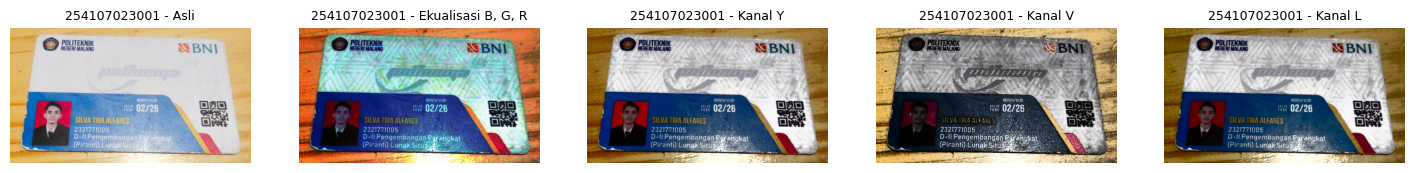

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            181.7
Ekualisasi B, G, R                46.49            129.6
Kanal Y                            1.40            131.2
Kanal V                            3.36            118.2
Kanal L                            7.55            124.2


In [24]:
# E-2 PERCOBAAN HISTOGRAM EQUALIZATION
# 3.  Ekualisasi Kanal Warna Terpisah / BGR
# 4.    Ekualisasi Kanal Kecerahan & Analisis Pergeseran Hue

berkas = BASE + '/KTM1d.jpg'  # Ganti dengan path citra lu
if os.path.exists(berkas):
    bgr = cv.imread(berkas)

    # Cara 1: Ekualisasi tiap kanal B, G, R sendiri-sendiri
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # Cara 2: Hanya kanal terang yang diekualisasi (YCrCb, HSV, LAB)
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # Fungsi pengukur pergeseran Hue
    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d) # Hue melingkar 0-179
        return d.mean()

    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    # Plot kelima citra berdampingan
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(NIM + ' - ' + t, fontsize=9)
        plt.axis('off')
    plt.show()

    # Cetak tabel pergeseran Hue dan rerata terang
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    for t, c in zip(judul, citra):
        print('%-22s %16.2f %16.1f' % (t, geser_hue(bgr, c) * 2, cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()))
else:
    print(f"File KTM1d.jpg tidak ditemukan di {berkas}")

In [29]:
# # E-2 PERCOBAAN HISTOGRAM EQUALIZATION
# # 4 (Lanjutan). Perbandingan Ekualisasi Biasa dengan CLAHE
if os.path.exists(berkas):
    bgr_img = cv.imread(berkas)
    lab_img = cv.cvtColor(bgr_img, cv.COLOR_BGR2LAB)
    l_chan, a_chan, b_chan = cv.split(lab_img)

    # 1. Ekualisasi Biasa (cv.equalizeHist)
    eq_l = cv.equalizeHist(l_chan)
    res_biasa = cv.cvtColor(cv.merge([eq_l, a_chan, b_chan]), cv.COLOR_LAB2BGR)

    # 2. CLAHE (menggunakan PARAM dari NIM)
    clahe = cv.createCLAHE(clipLimit=PARAM['clip'], tileGridSize=(PARAM['tile'], PARAM['tile']))
    clahe_l = clahe.apply(l_chan)
    res_clahe = cv.cvtColor(cv.merge([clahe_l, a_chan, b_chan]), cv.COLOR_LAB2BGR)

    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)
        return d.mean()

    hue_biasa = geser_hue(bgr_img, res_biasa) * 2
    bright_biasa = cv.cvtColor(res_biasa, cv.COLOR_BGR2GRAY).mean()

    hue_clahe = geser_hue(bgr_img, res_clahe) * 2
    bright_clahe = cv.cvtColor(res_clahe, cv.COLOR_BGR2GRAY).mean()

    print(f"--- Perbandingan Kanal L (LAB): Biasa vs CLAHE ---")
    print(f"Biasa  -> Geser Hue: {hue_biasa:.2f}°, Rerata Terang: {bright_biasa:.1f}")
    print(f"CLAHE  -> Geser Hue: {hue_clahe:.2f}°, Rerata Terang: {bright_clahe:.1f} (Clip: {PARAM['clip']}, Tile: {PARAM['tile']}x{PARAM['tile']})")

--- Perbandingan Kanal L (LAB): Biasa vs CLAHE ---
Biasa  -> Geser Hue: 7.55°, Rerata Terang: 124.2
CLAHE  -> Geser Hue: 5.29°, Rerata Terang: 168.6 (Clip: 1.5, Tile: 3x3)


/tmp/ipykernel_2288/974510403.py:33: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='black')
/tmp/ipykernel_2288/974510403.py:35: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 1].hist(res_manual.ravel(), 256, [0, 256], color='blue')
/tmp/ipykernel_2288/974510403.py:37: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  axs[1, 2].hist(res_cv.ravel(), 256, [0, 256], color='green')


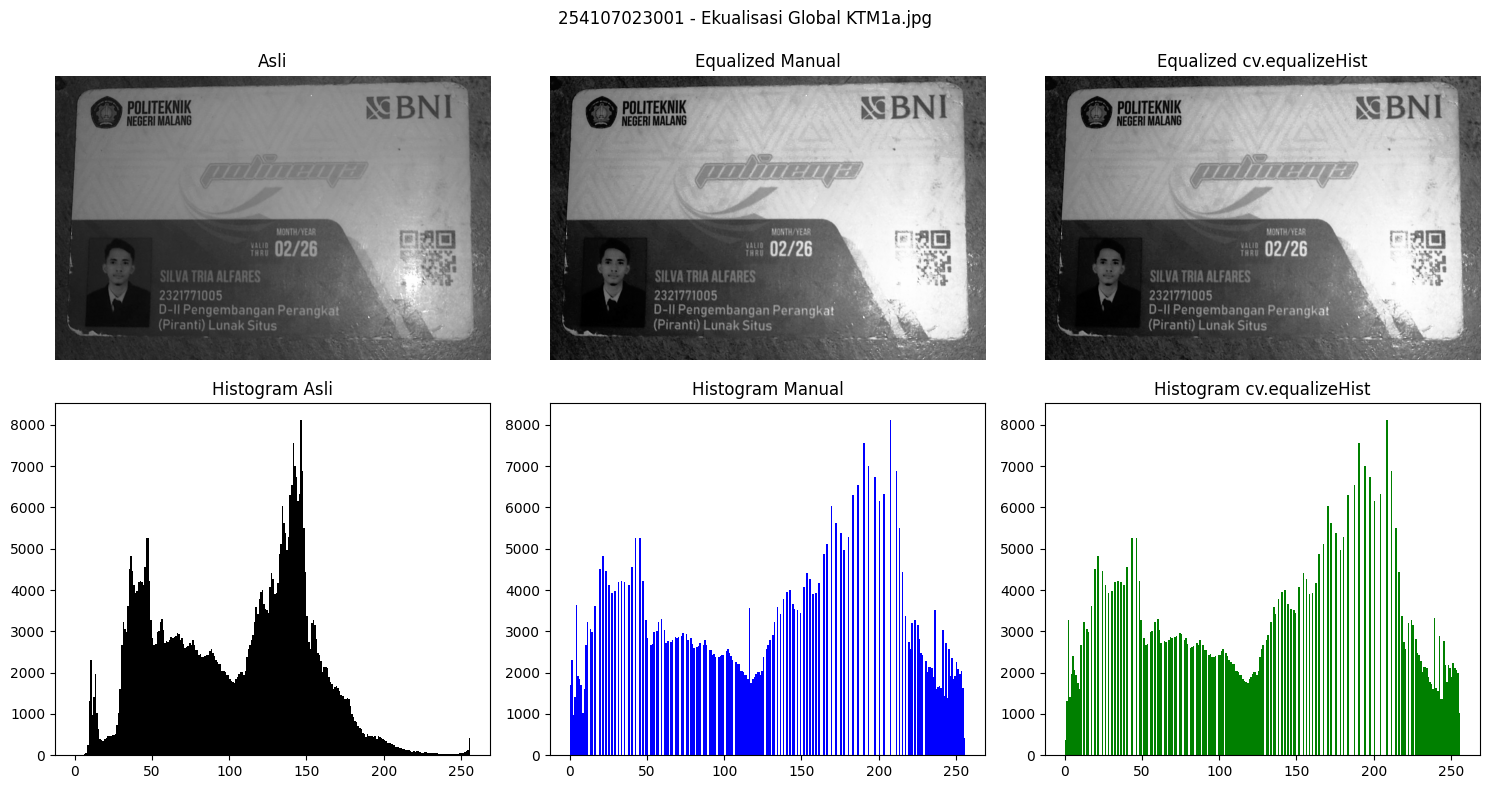

Nilai PSNR (Asli vs Equalized): 16.77 dB


In [37]:
# # E-2 PERCOBAAN HISTOGRAM EQUALIZATION
# # Pertanyaan 1: Ekualisasi Global (Manual, cv.equalizeHist, Plot, PSNR)
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

path_ktm1a = BASE + '/KTM1a.jpg'
if os.path.exists(path_ktm1a):
    # 1.a & 1.b: Terapkan ekualisasi manual & cv.equalizeHist pada citra grayscale, lalu plot layout
    img_gray = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

    # Fungsi manual
    hist, _ = np.histogram(img_gray.flatten(), 256, [0, 256])
    cdf = hist.cumsum()
    cdf_m = np.ma.masked_equal(cdf, 0)
    cdf_m = (cdf_m - cdf_m.min()) * 255 / (cdf_m.max() - cdf_m.min())
    res_manual = np.ma.filled(cdf_m, 0).astype('uint8')[img_gray]

    # Fungsi OpenCV
    res_cv = cv.equalizeHist(img_gray)

    # Plotting layout (Citra Asli, Hasil Manual, Hasil CV, beserta Histogramnya)
    fig, axs = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(f"{NIM} - Ekualisasi Global KTM1a.jpg")

    # Baris 1: Citra
    axs[0, 0].imshow(img_gray, cmap='gray'), axs[0, 0].set_title('Asli'), axs[0, 0].axis('off')
    axs[0, 1].imshow(res_manual, cmap='gray'), axs[0, 1].set_title('Equalized Manual'), axs[0, 1].axis('off')
    axs[0, 2].imshow(res_cv, cmap='gray'), axs[0, 2].set_title('Equalized cv.equalizeHist'), axs[0, 2].axis('off')

    # Baris 2: Histogram
    axs[1, 0].hist(img_gray.ravel(), 256, [0, 256], color='black')
    axs[1, 0].set_title('Histogram Asli')
    axs[1, 1].hist(res_manual.ravel(), 256, [0, 256], color='blue')
    axs[1, 1].set_title('Histogram Manual')
    axs[1, 2].hist(res_cv.ravel(), 256, [0, 256], color='green')
    axs[1, 2].set_title('Histogram cv.equalizeHist')

    plt.tight_layout()
    plt.show()

    # 1.c: Hitung PSNR antara citra asli dan citra hasil ekualisasi OpenCV
    psnr_value = cv.PSNR(img_gray, res_cv)
    print(f"Nilai PSNR (Asli vs Equalized): {psnr_value:.2f} dB")
else:
    print(f"File KTM1a.jpg tidak ditemukan di {path_ktm1a}")

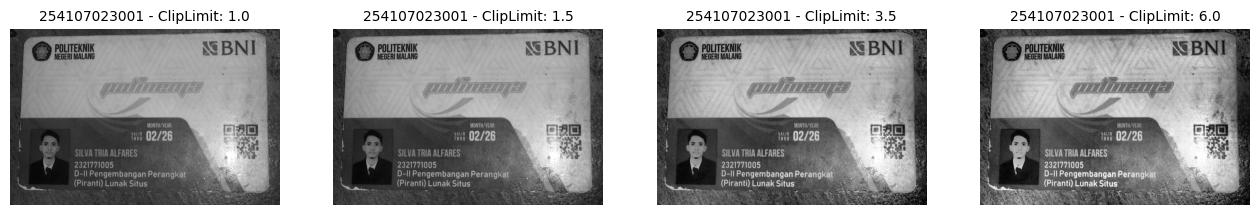

In [31]:
# PERTANYAAN PRAKTIKUM E2
# Pertanyaan 2: Ekualisasi Lokal dengan CLAHE & Variasi clipLimit
if os.path.exists(path_ktm1a):
    img_gray = cv.imread(path_ktm1a, cv.IMREAD_GRAYSCALE)

    # 2.a: CLAHE menggunakan PARAM dari NIM
    clip_default = PARAM['clip']
    tile_size = (PARAM['tile'], PARAM['tile'])

    clahe_def = cv.createCLAHE(clipLimit=clip_default, tileGridSize=tile_size)
    res_def = clahe_def.apply(img_gray)

    # 2.b: Tiga nilai clipLimit lain di sekitar nilai PARAM['clip']
    # Misalkan PARAM['clip'] bernilai X, kita ambil 3 variasi misal: clip rendah, sedang, tinggi
    c1 = max(1.0, clip_default - 1.0)
    c2 = clip_default
    c3 = clip_default + 2.0
    c4 = clip_default + 4.5

    variasi_clip = [c1, c2, c3, c4]

    plt.figure(figsize=(16, 4))
    for i, c in enumerate(variasi_clip, 1):
        clahe_var = cv.createCLAHE(clipLimit=c, tileGridSize=tile_size)
        res_var = clahe_var.apply(img_gray)

        plt.subplot(1, 4, i)
        plt.imshow(res_var, cmap='gray')
        plt.title(f"{NIM} - ClipLimit: {c}", fontsize=10)
        plt.axis('off')
    plt.show()
else:
    print(f"File KTM1a.jpg tidak ditemukan di {path_ktm1a}")

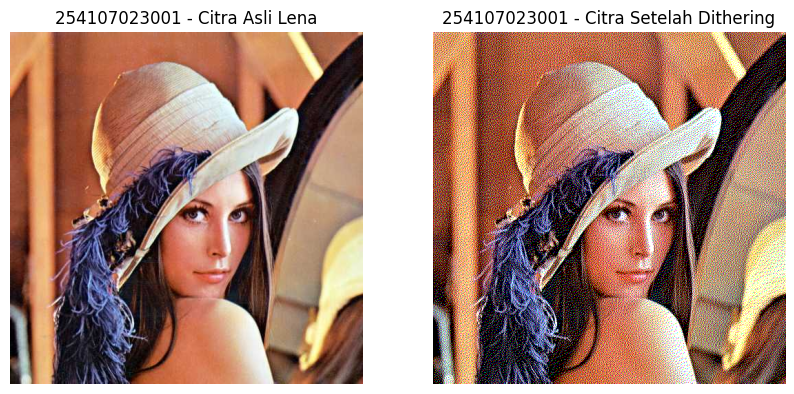

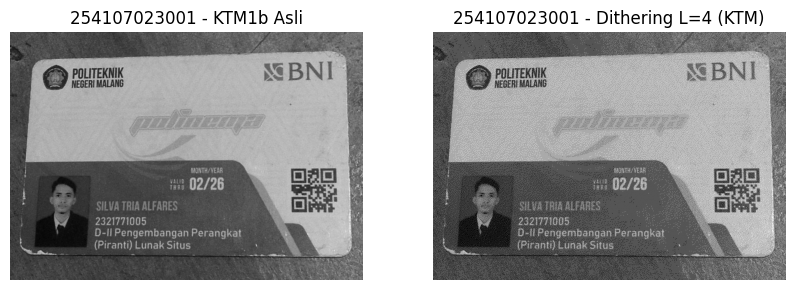

In [36]:
# E-3 TUGAS PRAKTIKUM DITHERING
# 1. Dithering Floyd-Steinberg (Support Citra Berwarna & Grayscale)
import os
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

def floyd_steinberg(img_input, L):
    img = img_input.astype(np.float32)
    step = 255.0 / (L - 1) if L > 1 else 255.0

    # Cek apakah citra berwarna (3 kanal) atau grayscale (2 kanal)
    if len(img.shape) == 3:
        H, W, C = img.shape
        for c in range(C):
            for y in range(H):
                for x in range(W):
                    lama = img[y, x, c]
                    baru = round(lama / step) * step
                    img[y, x, c] = baru
                    error = lama - baru

                    if x + 1 < W:
                        img[y, x + 1, c] += error * 7 / 16
                    if x > 0 and y + 1 < H:
                        img[y + 1, x - 1, c] += error * 3 / 16
                    if y + 1 < H:
                        img[y + 1, x, c] += error * 5 / 16
                    if x + 1 < W and y + 1 < H:
                        img[y + 1, x + 1, c] += error * 1 / 16
    else:
        H, W = img.shape
        for y in range(H):
            for x in range(W):
                lama = img[y, x]
                baru = round(lama / step) * step
                img[y, x] = baru
                error = lama - baru

                if x + 1 < W:
                    img[y, x + 1] += error * 7 / 16
                if x > 0 and y + 1 < H:
                    img[y + 1, x - 1] += error * 3 / 16
                if y + 1 < H:
                    img[y + 1, x] += error * 5 / 16
                if x + 1 < W and y + 1 < H:
                    img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

# --- TAHAP 1: lena.jpg (Berwarna, L=2) ---
path_lena = CONTOH + '/lena.jpg'
if os.path.exists(path_lena):
    lena_bgr = cv.imread(path_lena)
    lena_dither = floyd_steinberg(lena_bgr, L=2)

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(cv.cvtColor(lena_bgr, cv.COLOR_BGR2RGB))
    axs[0].set_title(f"{NIM} - Citra Asli Lena"), axs[0].axis('off')
    axs[1].imshow(cv.cvtColor(lena_dither, cv.COLOR_BGR2RGB))
    axs[1].set_title(f"{NIM} - Citra Setelah Dithering"), axs[1].axis('off')
    plt.show()

# --- TAHAP 2: KTM1b.jpg (Grayscale dengan level PARAM['L']) ---
path_ktm1b = BASE + '/KTM1b.jpg'
if os.path.exists(path_ktm1b):
    ktm_gray = cv.imread(path_ktm1b, cv.IMREAD_GRAYSCALE)
    ktm_dither = floyd_steinberg(ktm_gray, L=PARAM['L'])

    fig, axs = plt.subplots(1, 2, figsize=(10, 5))
    axs[0].imshow(ktm_gray, cmap='gray'), axs[0].set_title(f"{NIM} - KTM1b Asli"), axs[0].axis('off')
    axs[1].imshow(ktm_dither, cmap='gray'), axs[1].set_title(f"{NIM} - Dithering L={PARAM['L']} (KTM)"), axs[1].axis('off')
    plt.show()

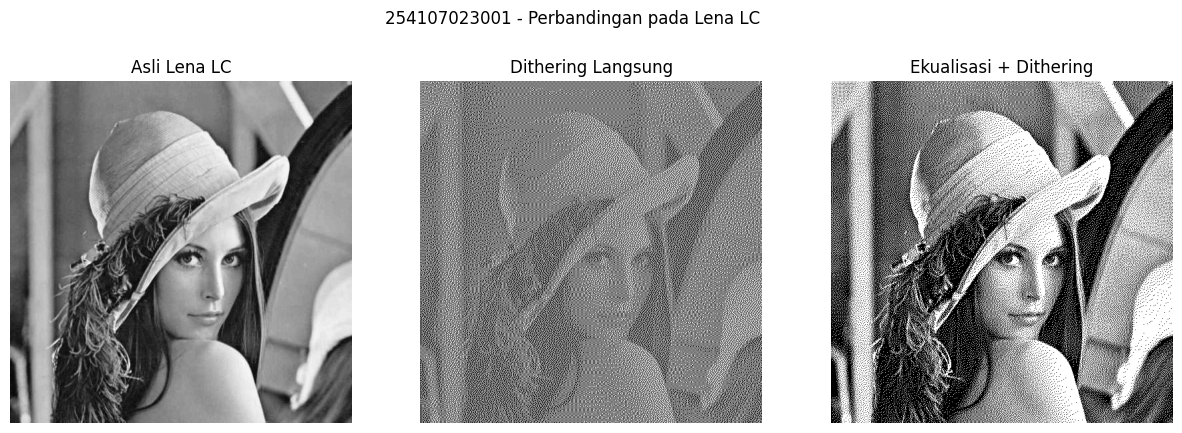

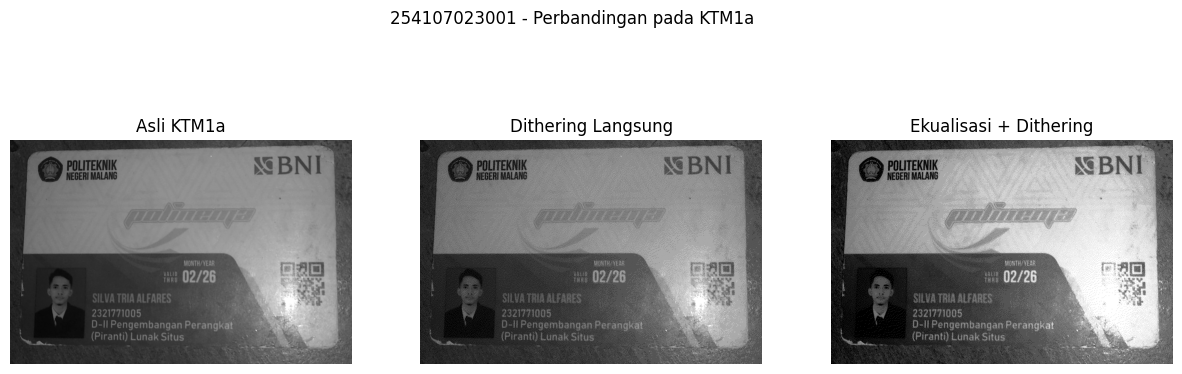

In [33]:
# # E-3 TUGAS PRAKTIKUM DITHERING
# # 2. Kombinasi Histogram Equalization & Dithering Floyd-Steinberg
path_lena_lc = CONTOH + '/lena_lc.jpg'
path_ktm1a = BASE + '/KTM1a.jpg'

def proses_eq_dither(image_path, L):
    if not os.path.exists(image_path):
        print(f"File tidak ditemukan: {image_path}")
        return

    img = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

    # 1. Dithering Langsung (tanpa ekualisasi)
    dither_langsung = floyd_steinberg(img, L)

    # 2. Ekualisasi dulu, baru Dithering
    img_eq = cv.equalizeHist(img)
    dither_eq = floyd_steinberg(img_eq, L)

    return img, dither_langsung, img_eq, dither_eq

# Uji pada lena_lc.jpg (mencocokkan contoh)
if os.path.exists(path_lena_lc):
    asli, d_langsung, eq_img, d_eq = proses_eq_dither(path_lena_lc, L=2)

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(asli, cmap='gray'), axs[0].set_title('Asli Lena LC'), axs[0].axis('off')
    axs[1].imshow(d_langsung, cmap='gray'), axs[1].set_title('Dithering Langsung'), axs[1].axis('off')
    axs[2].imshow(d_eq, cmap='gray'), axs[2].set_title('Ekualisasi + Dithering'), axs[2].axis('off')
    plt.suptitle(f"{NIM} - Perbandingan pada Lena LC")
    plt.show()

# Uji pada KTM1a.jpg
if os.path.exists(path_ktm1a):
    asli_ktm, d_langsung_ktm, eq_ktm, d_eq_ktm = proses_eq_dither(path_ktm1a, L=PARAM['L'])

    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].imshow(asli_ktm, cmap='gray'), axs[0].set_title('Asli KTM1a'), axs[0].axis('off')
    axs[1].imshow(d_langsung_ktm, cmap='gray'), axs[1].set_title('Dithering Langsung'), axs[1].axis('off')
    axs[2].imshow(d_eq_ktm, cmap='gray'), axs[2].set_title('Ekualisasi + Dithering'), axs[2].axis('off')
    plt.suptitle(f"{NIM} - Perbandingan pada KTM1a")
    plt.show()